# (12) leapfrog, load, analyze: (32x2, 64.0x1.0)

project = ```iP-VAE```, host = ```chewie```, device = ```cuda:1```

**Motivation**: <br>

Load the best-looking leapfrog fit and analyze.

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
# from analysis.eval import sparse_score
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from figures.analysis import plot_convergence
from figures.imgs import plot_weights


device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## Load trainer

In [3]:
cm = 'learned-dt'
model_name = 'poisson_vH16_t-32×2_b-1_z-[512]_<leapfrog|lin>'
fit_name = 'b200-ep300-lr(0.002)_beta(64:0x0.1)_temp(0.05:lin-0.5)_gr(200)_(2025_02_11,09:02)'

tr, meta = load_model(f"{model_name}/{cm}_{fit_name}", False, device=device)

In [5]:
print(tr.model.layer.n_exp)

tensor([26, 32, 41, 53, 65, 77, 86, 92, 96, 98, 98, 99, 99, 99, 99, 98, 98, 98,
        98, 98, 98, 98, 98, 98, 98, 98, 98, 98, 98, 97, 98, 97],
       device='cuda:1', dtype=torch.int32)

In [11]:
msg = f"inner learning rate: {tr.model.layer.log_lr.exp().item():0.2f}\n"
msg += f"inner gamma : {tr.model.layer.log_gamma.exp().item():0.2f}\n"
msg += f"inner dt: {tr.model.layer.log_dt.exp().item():0.2f}\n"

print(msg)

inner learning rate: 1.24
inner gamma : 2.50
inner dt: 0.19

100%|███████████████████████████████████| 2/2 [01:25<00:00, 42.90s/it]


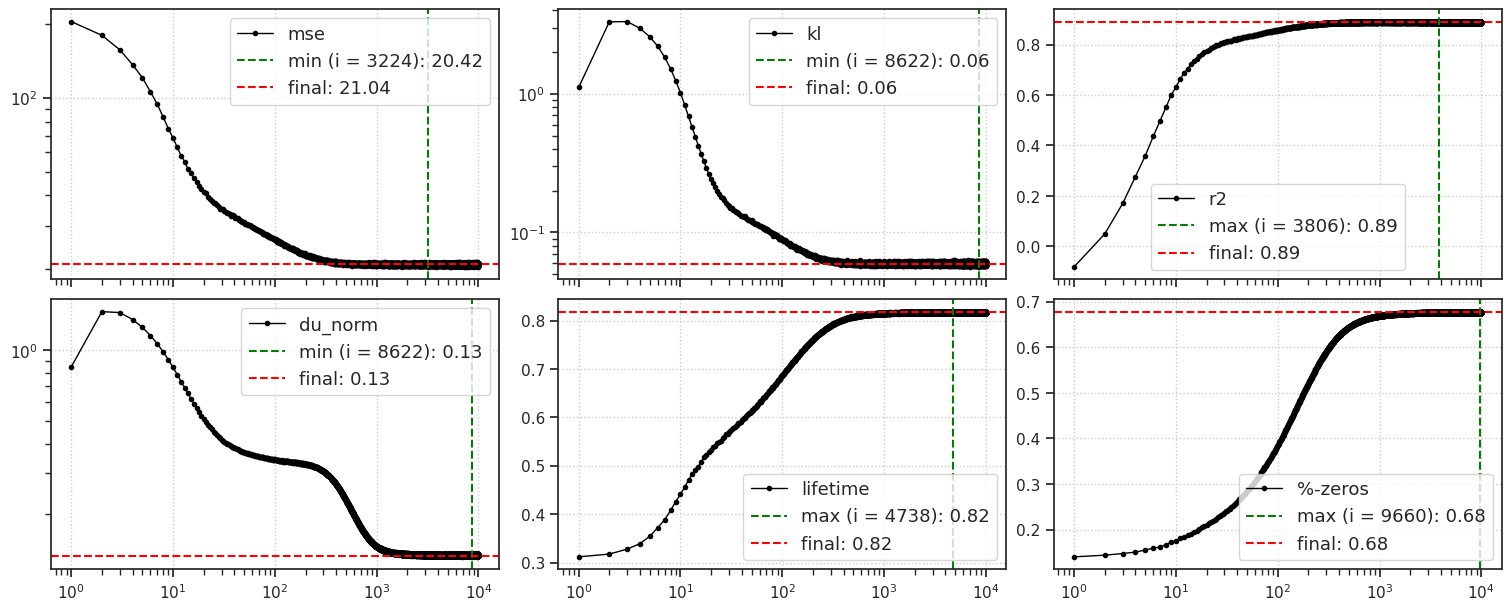

In [4]:
kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

In [12]:
output = tr.model.xtract_ftr(
    feeder=tr.get_feeder(),
    seq=range(1000),
    return_extras=True,
).stack()

print(list(output))

['loss_kl', 'loss_recon', 'posterior', 'du', 'u', 'v', 'recon', 'samples', 'conditional', 'mse', 'r2']

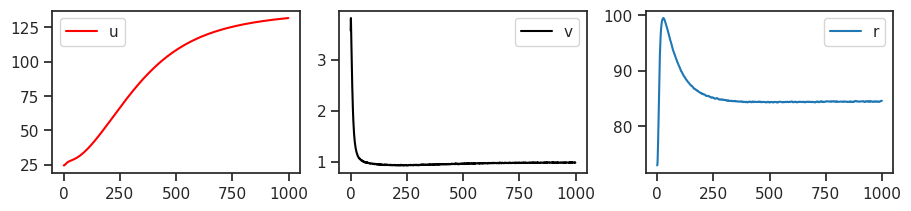

In [13]:
u_norm = tonp(torch.linalg.norm(output['u'], axis=-1).mean(0))
v_norm = tonp(torch.linalg.norm(output['v'], axis=-1).mean(0))
r_norm = tonp(torch.linalg.norm(torch.exp(output['u']), axis=-1).mean(0))


fig, axes = create_figure(1, 3)
axes[0].plot(u_norm, label='u', color='r')
axes[1].plot(v_norm, label='v', color='k')
axes[2].plot(r_norm, label='r')

# for ax in axes.flat:
#     ax.set(xscale='log', yscale='log')

add_legend(axes)
plt.show()

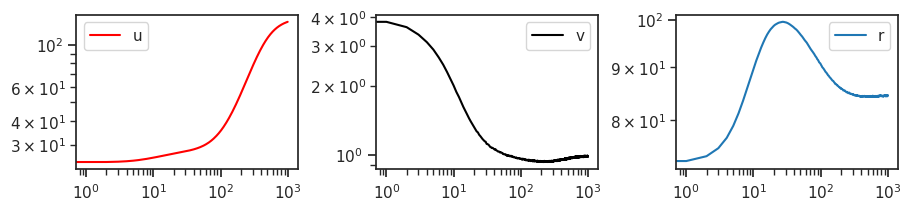

In [14]:
fig, axes = create_figure(1, 3)
axes[0].plot(u_norm, label='u', color='r')
axes[1].plot(v_norm, label='v', color='k')
axes[2].plot(r_norm, label='r')

for ax in axes.flat:
    ax.set(xscale='log', yscale='log')

add_legend(axes)
plt.show()

tensor([20.8062, 20.6166, 20.8670, 20.6171, 20.4394], device='cuda:1')

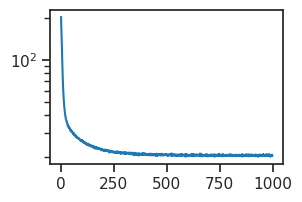

In [15]:
feeder = tr.get_feeder()

locs = torch.stack([
    p.loc for p in
    output['conditional'].values()
], dim=1)
mse = (locs - feeder[0].unsqueeze(1)).pow(2).sum(-1)
plot(mse.mean(0))
plt.yscale('log');

mse.mean(0)[-5:]

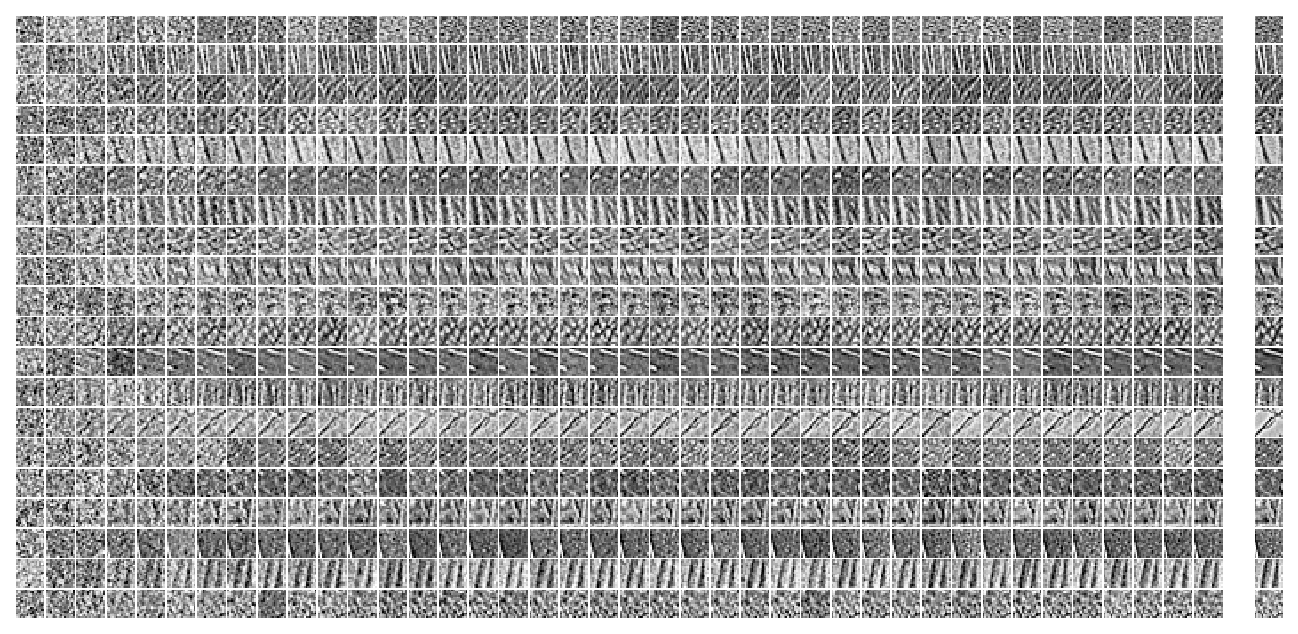

In [16]:
num = 20
n_timepoints = 40

x2p = tonp(locs)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)

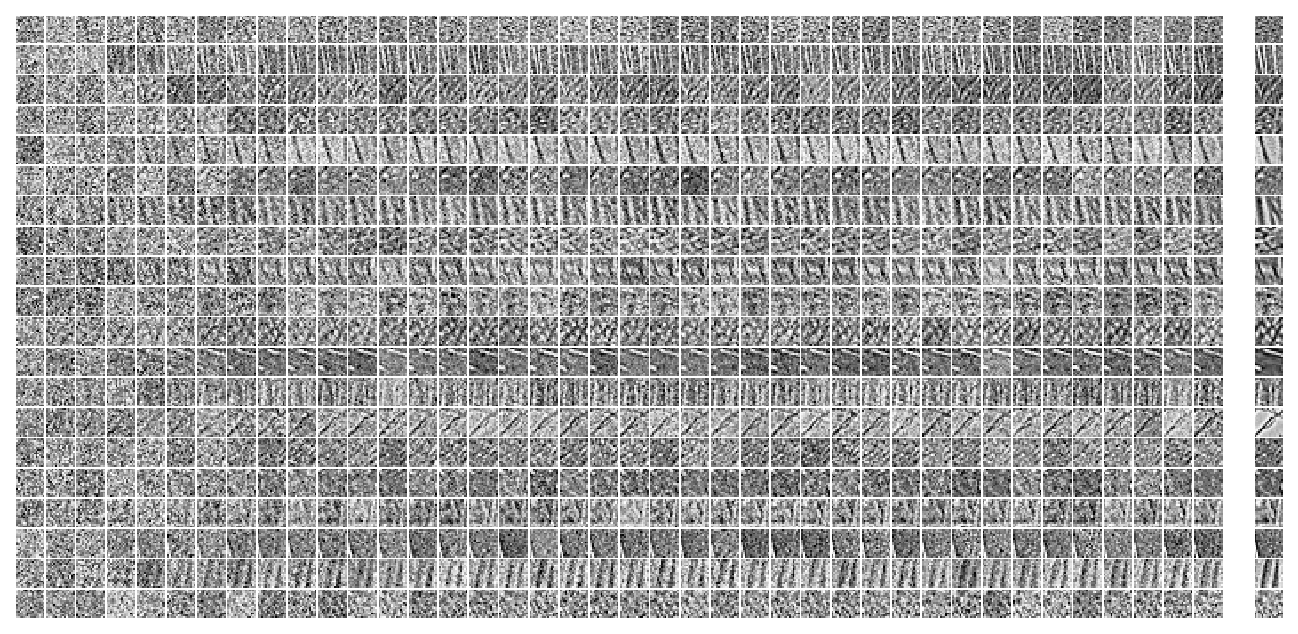

In [17]:
x2p = tonp(output['recon'])[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)

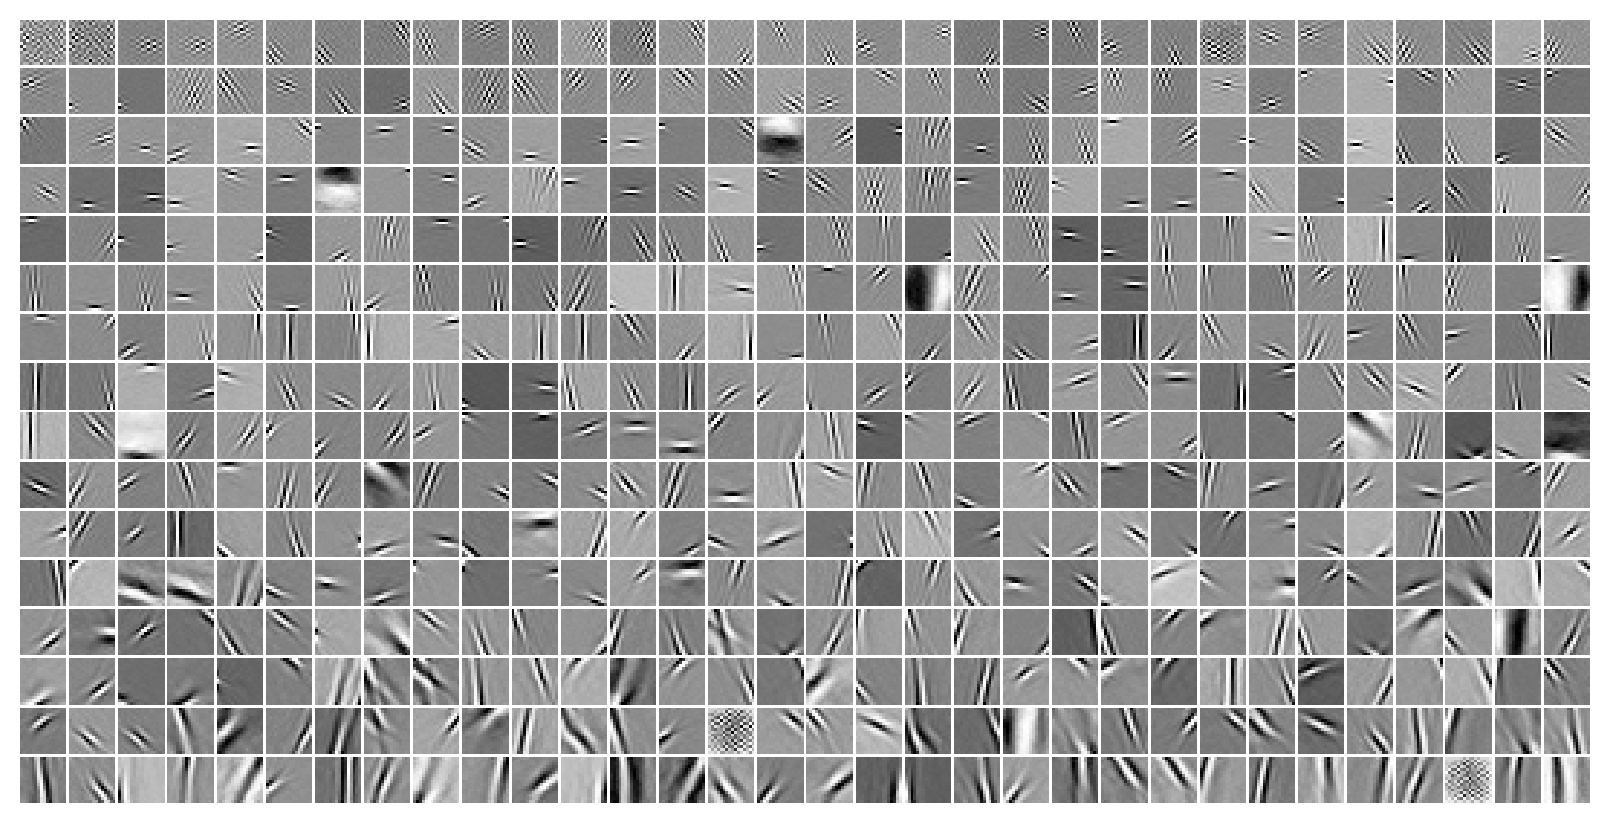

In [18]:
u0 = tonp(tr.model.layer.u_init.squeeze())
tr.model.show(order=np.argsort(u0));

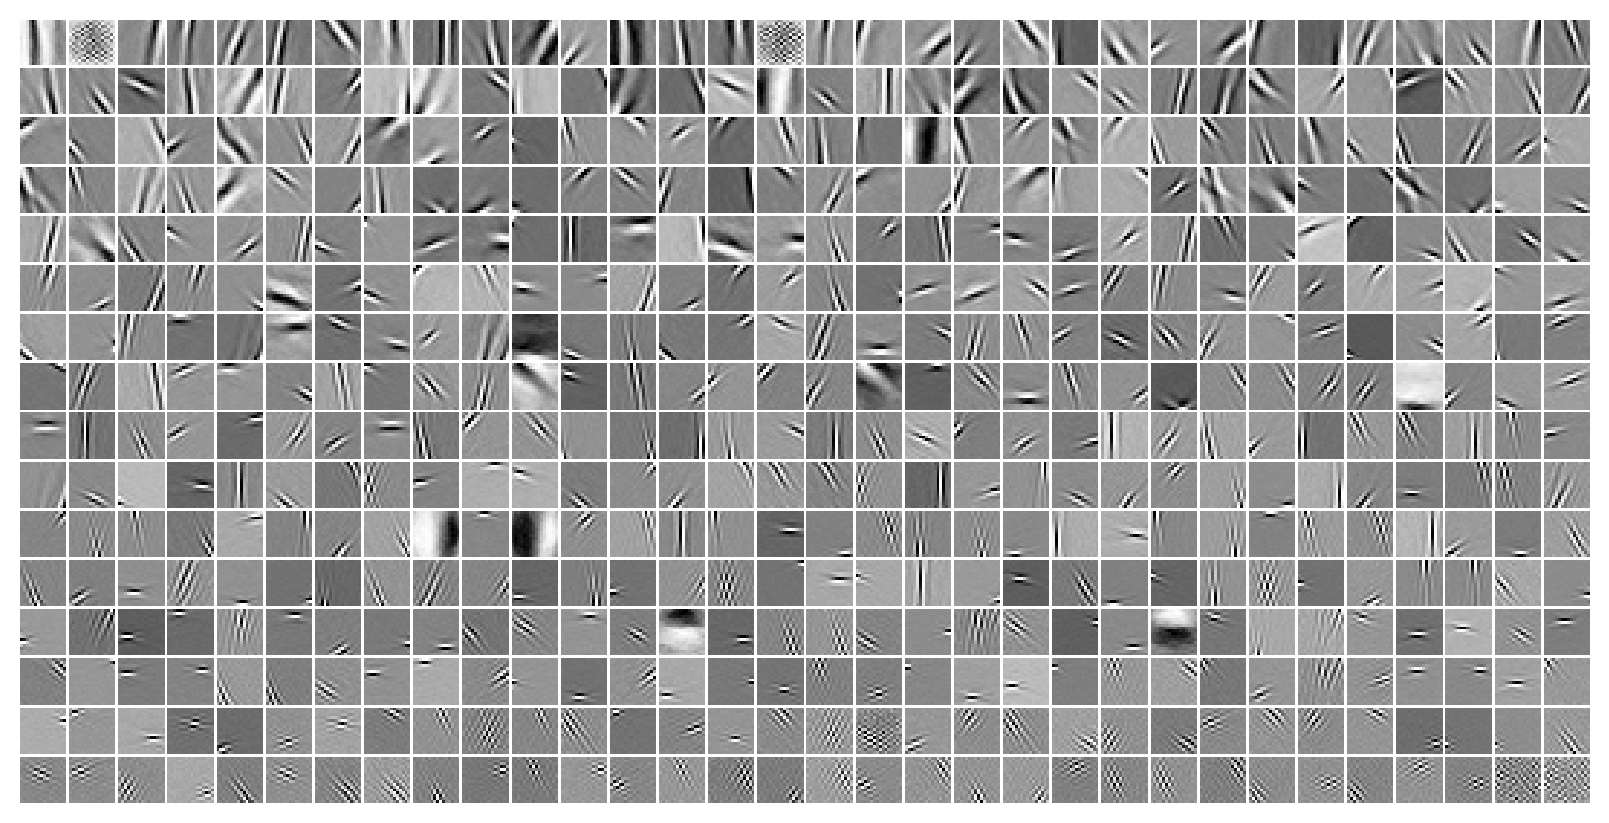

In [19]:
bias = tonp(tr.model.layer.log_bias.squeeze().exp())
tr.model.show(order=np.argsort(bias));

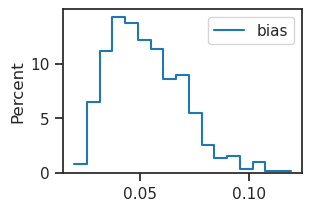

In [28]:
fig, ax = create_figure()

histplot(bias, label='bias', stat='percent',  ax=ax)
ax.locator_params(axis='x', nbins=3)
ax.legend()
plt.show()

In [50]:
sp_stats.pearsonr(u0, bias)

PearsonRResult(statistic=-0.9939344935381687, pvalue=0.0)

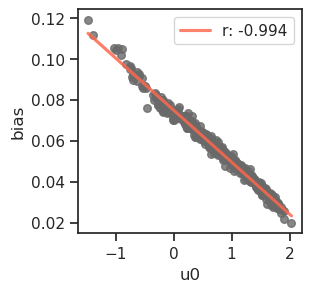

In [53]:
slope, intercept, r_value, p_value, std_err = sp_stats.linregress(u0, bias)

fig, ax = create_figure(1, 1, (3, 3))

scatter_kws = {'s': 30, 'color': 'dimgrey'}
line_kws = {'label': f'r: {r_value:.3f}', 'color': 'tomato', 'alpha': 0.8}
sns.regplot(x=u0, y=bias, scatter_kws=scatter_kws, line_kws=line_kws, ax=ax)

ax.set(xlabel='u0', ylabel='bias')
ax_square(ax)
ax.legend()

plt.show()

## black screen

In [142]:
output = tr.model.xtract_ftr(
    feeder=tr.get_feeder(),
    seq=range(500),
    return_extras=True,
).stack()

print(list(output))

['loss_kl', 'loss_recon', 'posterior', 'du', 'u', 'v', 'recon', 'samples', 'conditional', 'mse', 'r2']

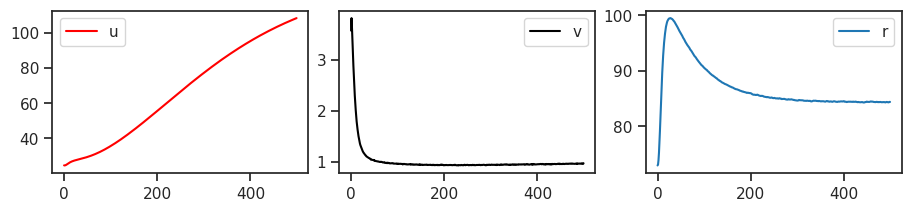

In [143]:
u_norm = tonp(torch.linalg.norm(output['u'], axis=-1).mean(0))
v_norm = tonp(torch.linalg.norm(output['v'], axis=-1).mean(0))
r_norm = tonp(torch.linalg.norm(torch.exp(output['u']), axis=-1).mean(0))


fig, axes = create_figure(1, 3)
axes[0].plot(u_norm, label='u', color='r')
axes[1].plot(v_norm, label='v', color='k')
axes[2].plot(r_norm, label='r')

# for ax in axes.flat:
#     ax.set(xscale='log', yscale='log')

add_legend(axes)
plt.show()

In [144]:
shape = tr.model.cfg.shape
shape = (tr.cfg.batch_size, *shape[1:])
x_zeros = tr.to(torch.zeros(shape))

feeder_zeros = tr.get_feeder(x_zeros)

x.shape

torch.Size([200, 1, 16, 16])

In [145]:
output_zeros = tr.model.xtract_ftr(
    feeder=feeder_zeros,
    seq=range(500, 1000),
    return_extras=True,
).stack()

print(list(output_zeros))

['loss_kl', 'loss_recon', 'posterior', 'du', 'u', 'v', 'recon', 'samples', 'conditional', 'mse', 'r2']

In [146]:
u_norm_zeros = tonp(torch.linalg.norm(output_zeros['u'], axis=-1).mean(0))
v_norm_zeros = tonp(torch.linalg.norm(output_zeros['v'], axis=-1).mean(0))
r_norm_zeros = tonp(torch.linalg.norm(torch.exp(output_zeros['u']), axis=-1).mean(0))

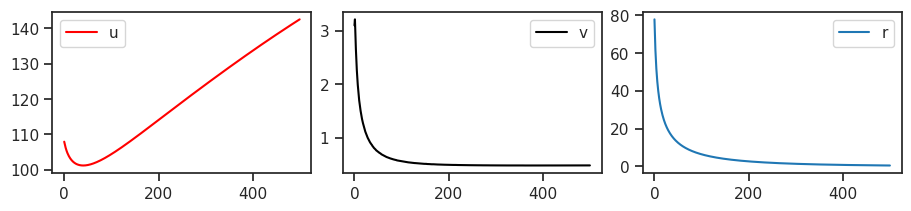

In [147]:
fig, axes = create_figure(1, 3)
axes[0].plot(u_norm_zeros, label='u', color='r')
axes[1].plot(v_norm_zeros, label='v', color='k')
axes[2].plot(r_norm_zeros, label='r')

add_legend(axes)
plt.show()

In [148]:
u0_norm = torch.linalg.norm(tr.model.layer.u_init, dim=-1)
v0_norm = torch.linalg.norm(tr.model.layer.v_init, dim=-1)
r0_norm = torch.linalg.norm(tr.model.layer.u_init.exp(), dim=-1)

u0_norm, v0_norm, r0_norm

(tensor([24.5004], device='cuda:1', grad_fn=<LinalgVectorNormBackward0>),
 tensor([0.4641], device='cuda:1', grad_fn=<LinalgVectorNormBackward0>),
 tensor([72.9721], device='cuda:1', grad_fn=<LinalgVectorNormBackward0>))

In [149]:
u_norm_all = np.concatenate([tonp(u0_norm), u_norm, u_norm_zeros])
v_norm_all = np.concatenate([tonp(v0_norm), v_norm, v_norm_zeros])
r_norm_all = np.concatenate([tonp(r0_norm), r_norm, r_norm_zeros])

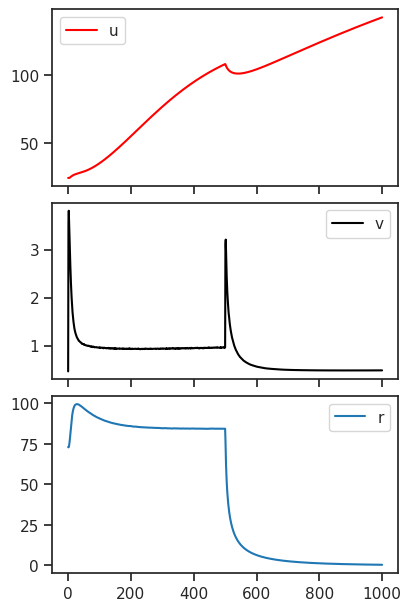

In [152]:
fig, axes = create_figure(3, 1, (4, 6), sharex='all')
axes[0].plot(u_norm_all, label='u', color='r')
axes[1].plot(v_norm_all, label='v', color='k')
axes[2].plot(r_norm_all, label='r')

add_legend(axes)
plt.show()

## gray -> img -> gray

In [153]:
shape = tr.model.cfg.shape
shape = (tr.cfg.batch_size, *shape[1:])

contrast = 0.35
x_gray = torch.ones(shape) * contrast
x_gray = tr.to(x_gray)

feeder_gray = tr.get_feeder(x_gray)

In [ ]:
output_1 = tr.model.xtract_ftr(
    feeder=feeder_gray,
    seq=range(0, 1000),
    return_extras=True,
).stack()

output_2 = tr.model.xtract_ftr(
    feeder=tr.get_feeder(),
    seq=range(1000, 2000),
    return_extras=True,
).stack()

output_3 = tr.model.xtract_ftr(
    feeder=feeder_gray,
    seq=range(2000, 3000),
    return_extras=True,
).stack()

In [ ]:
u0_norm = tonp(torch.linalg.norm(tr.model.layer.u_init, dim=-1))
v0_norm = tonp(torch.linalg.norm(tr.model.layer.v_init, dim=-1))
r0_norm = tonp(torch.linalg.norm(tr.model.layer.u_init.exp(), dim=-1))

u0_norm, v0_norm, r0_norm

In [ ]:
u_norm_all = np.concatenate([
    u0_norm,
    tonp(torch.linalg.norm(output_1['u'], axis=-1).mean(0)),
    tonp(torch.linalg.norm(output_2['u'], axis=-1).mean(0)),
    tonp(torch.linalg.norm(output_3['u'], axis=-1).mean(0)),
])
v_norm_all = np.concatenate([
    v0_norm,
    tonp(torch.linalg.norm(output_1['v'], axis=-1).mean(0)),
    tonp(torch.linalg.norm(output_2['v'], axis=-1).mean(0)),
    tonp(torch.linalg.norm(output_3['v'], axis=-1).mean(0)),
])
r_norm_all = np.concatenate([
    r0_norm,
    tonp(torch.linalg.norm(torch.exp(output_1['u']), axis=-1).mean(0)),
    tonp(torch.linalg.norm(torch.exp(output_2['u']), axis=-1).mean(0)),
    tonp(torch.linalg.norm(torch.exp(output_3['u']), axis=-1).mean(0)),
])

In [ ]:
fig, axes = create_figure(3, 1, (4, 6), sharex='all')
axes[0].plot(u_norm_all, label='u', color='r')
axes[1].plot(v_norm_all, label='v', color='k')
axes[2].plot(r_norm_all, label='r')

add_legend(axes)
plt.show()